In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pulsed_tools import *

In [20]:

channel_map = {
    'resonant': 1,
    'Pulse_2': 2,
    'Trigger': 5,      # Available but not used in this sequence
    'Microwave': 7,    # Available but not used in this sequence
}


## T1 measurements

--- Creating sweep sequence with 50 steps ---
Total continuous sequence duration: 9752.48 µs
--- Generating Plot: Time Delay Sweep (First 3 Steps) ---


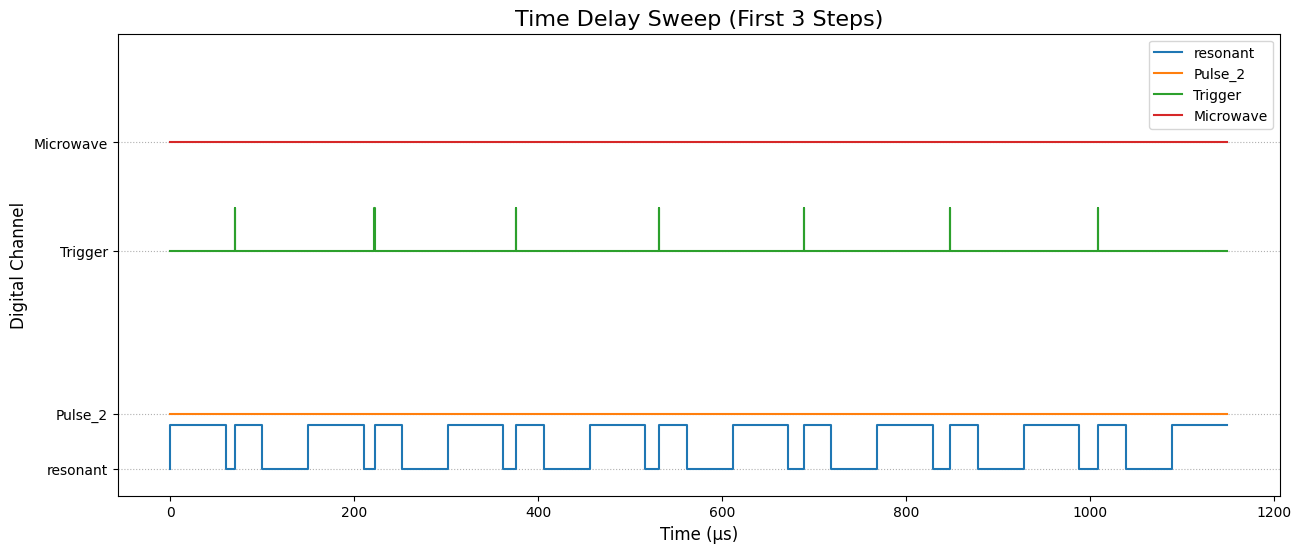

In [34]:

PULSE_1_DURATION_US_initialize = 60
PULSE_1_DURATION_US_readout = 30
PULSE_2_DURATION_US = 0
FIXED_WAIT_US = 50  # Fixed wait time after the second pulse
POST_PULSE_WAIT_US = 10
TRIGGER_DURATION_US: float = 0.05 # Duration for the trigger pulse, if used

wait_time_sweep = {
    'start': 10,    # Start with a 1 µs wait
    'end': 100,    # End with a 200 µs wait
    'steps': 50,  # Perform 50 steps as requested
}



def time_delay_subsequence_generator(swept_wait_time_us):
    """
    Generates the sequence: [100µs Pulse] -> [Swept Wait] -> [50µs Pulse] -> [Fixed Wait]
    """
    sub_sequence = [
        # Part 1: The starting 100 µs pulse
        {'duration_us': PULSE_1_DURATION_US_initialize, 'channels_on': ['resonant']},
        {'duration_us': swept_wait_time_us, 'channels_on': []},
        {'duration_us': TRIGGER_DURATION_US, 'channels_on': ['Trigger']},
        {'duration_us': PULSE_1_DURATION_US_readout, 'channels_on': ['resonant']},
        # Part 2: The variable waiting time, passed in as an argument
    
        {'duration_us': FIXED_WAIT_US, 'channels_on': []},
        # Part 3: The second 50 µs pulse
       
        # Part 4: A fixed wait/readout time before the next sequence starts
       
        
        
         

    ]
    return sub_sequence

full_sweep_sequence, total_duration = create_sweep_sequence(
    wait_time_sweep,
    time_delay_subsequence_generator,
    channel_map
)

one_step_duration = PULSE_1_DURATION_US_initialize + wait_time_sweep['start'] + PULSE_1_DURATION_US_readout + POST_PULSE_WAIT_US
plot_window = one_step_duration *10# Plot the first 3 cycles

plot_sequence(
    full_sweep_sequence,
    channel_map,
    plot_duration_us=plot_window,
    title="Time Delay Sweep (First 3 Steps)"
)

### Analysis

In [24]:
tagger._time_diff_sum_start = 0 # Start with the trigger
tagger._time_diff_sum_stop = 100000 # Stop after the readout pulse
tagger._time_diff_ref_start = 0
tagger._time_diff_ref_stop = 60000

In [52]:
tagger._time_diff_ref_start = 200000

## ODMR

--- Creating sweep sequence with 1 steps ---
Total continuous sequence duration: 300.05 µs
--- Generating Plot: Time Delay Sweep (First 3 Steps) ---


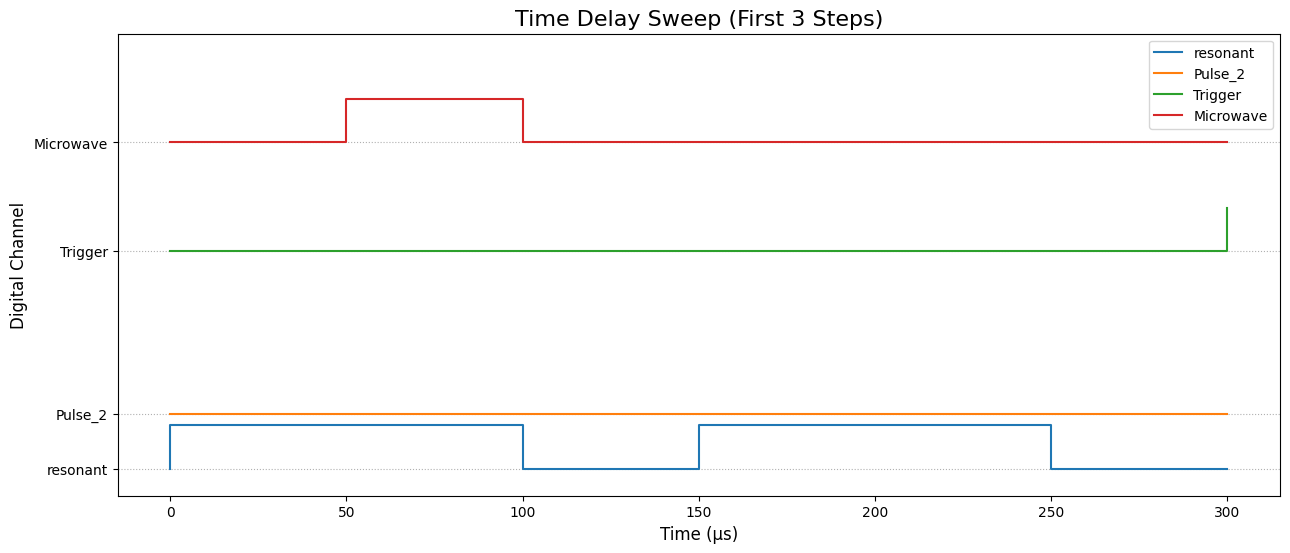

In [50]:

PULSE_1_DURATION_US = 50
MICROWAVE_DURATION_US = 50
PULSE_2_DURATION_US = 0

POST_PULSE_WAIT_US = 0
TRIGGER_DURATION_US: float = 0.05 # Duration for the trigger pulse, if used

START_WAIT_US = 50
END_WAIT_US = 50
STEPS = 1

wait_time_sweep = {
    'start': START_WAIT_US,    # Start with a 1 µs wait
    'end': END_WAIT_US,    # End with a 200 µs wait
    'steps': STEPS,  # Perform 50 steps as requested
}



def time_delay_subsequence_generator(swept_wait_time_us):
    """
    Generates the sequence: [100µs Pulse] -> [Swept Wait] -> [50µs Pulse] -> [Fixed Wait]
    """
    sub_sequence = [
        # Part 1: The starting 100 µs pulse
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['resonant']},
        {'duration_us': MICROWAVE_DURATION_US, 'channels_on': ['resonant', "Microwave"]},
        # Part 2: The variable waiting time, passed in as an argument
        {'duration_us': swept_wait_time_us, 'channels_on': []},
        
        # Reference Pulse
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['resonant']},
        {'duration_us': PULSE_1_DURATION_US, 'channels_on': ['resonant']},


         {'duration_us': PULSE_1_DURATION_US, 'channels_on': []},
        
        # Part 3: The second 50 µs pulse
       
        # Part 4: A fixed wait/readout time before the next sequence starts
       
        {'duration_us': TRIGGER_DURATION_US, 'channels_on': ['Trigger']},
        
         

    ]
    return sub_sequence

full_sweep_sequence, total_duration = create_sweep_sequence(
    wait_time_sweep,
    time_delay_subsequence_generator,
    channel_map
)

one_step_duration = PULSE_1_DURATION_US + wait_time_sweep['start'] + PULSE_2_DURATION_US + POST_PULSE_WAIT_US
plot_window = one_step_duration * 10 # Plot the first 3 cycles

plot_sequence(
    full_sweep_sequence,
    channel_map,
    plot_duration_us=plot_window,
    title="Time Delay Sweep (First 3 Steps)"
)

## Analysis

In [61]:
ni_tt_finite_sampling_input.pulsed = False
ni_tt_finite_sampling_input.use_ref = False


In [27]:
timetagger._mw.timeDiffChannelComboBox.currentText()

'1'

In [55]:
timetagger.update_time_diff()

In [9]:
# _save_folderpath = "C:/Users/YY3/GIT/squdi/src/qudi/jupyternotebooks/pulsed_measurments/"


In [10]:
timetagger

<qudi.gui.timetagger.timetagger.TTGui(0x25d809c5430) at 0x0000025D87F00C40>

In [40]:
timetagger.time_diff_use_ref = True

In [45]:
TOTAL_PULSE = PULSE_1_DURATION_US + MICROWAVE_DURATION_US
timetagger.time_diff_start_ns = PULSE_1_DURATION_US # Start with the trigger
timetagger.time_diff_stop_ns = TOTAL_PULSE # Stop after the readout pulse
timetagger.time_diff_ref_start_ns = TOTAL_PULSE + PULSE_1_DURATION_US + START_WAIT_US
timetagger.time_diff_ref_stop_ns = 2 * TOTAL_PULSE + START_WAIT_US

timetagger.time_diff_num_histograms = STEPS
timetagger.time_diff_bin_width = 100e3  # bin width picoseconds
timetagger.time_diff_record_length = total_duration

In [57]:
timetaggerlogic.metadata['time_diff']

# meta_dict = {'Click Channel': self.time_diff_click_channel, 
#                              'Start Channel': start_channel, 
#                              'Next Channel': next_channel,
#                              'Bin Width': int(self.time_diff_bin_width)/1e12, 
#                              'Number of Bins': number_of_bins, 
#                              'Number of Histograms': self.time_diff_num_histograms,
#                              'Use Reference': self.time_diff_use_ref,
#                              'Units': [('Counts','arb.')]}

{'Click Channel': 1, 'Start Channel': 5, 'Next Channel': 5, 'Bin Width': 1e-06, 'Number of Bins': 280, 'Number of Histograms': 200, 'Use Reference': False, 'Units': [('Counts', 'arb.')]}

In [58]:
timetaggerlogic.time_diff_data

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

In [46]:
timetaggerlogic.time_diff_data_raw

(array([0.00e+00, 1.00e-06, 2.00e-06, 3.00e-06, 4.00e-06, 5.00e-06,
       6.00e-06, 7.00e-06, 8.00e-06, 9.00e-06, 1.00e-05, 1.10e-05,
       1.20e-05, 1.30e-05, 1.40e-05, 1.50e-05, 1.60e-05, 1.70e-05,
       1.80e-05, 1.90e-05, 2.00e-05, 2.10e-05, 2.20e-05, 2.30e-05,
       2.40e-05, 2.50e-05, 2.60e-05, 2.70e-05, 2.80e-05, 2.90e-05,
       3.00e-05, 3.10e-05, 3.20e-05, 3.30e-05, 3.40e-05, 3.50e-05,
       3.60e-05, 3.70e-05, 3.80e-05, 3.90e-05, 4.00e-05, 4.10e-05,
       4.20e-05, 4.30e-05, 4.40e-05, 4.50e-05, 4.60e-05, 4.70e-05,
       4.80e-05, 4.90e-05, 5.00e-05, 5.10e-05, 5.20e-05, 5.30e-05,
       5.40e-05, 5.50e-05, 5.60e-05, 5.70e-05, 5.80e-05, 5.90e-05,
       6.00e-05, 6.10e-05, 6.20e-05, 6.30e-05, 6.40e-05, 6.50e-05,
       6.60e-05, 6.70e-05, 6.80e-05, 6.90e-05, 7.00e-05, 7.10e-05,
       7.20e-05, 7.30e-05, 7.40e-05, 7.50e-05, 7.60e-05, 7.70e-05,
       7.80e-05, 7.90e-05, 8.00e-05, 8.10e-05, 8.20e-05, 8.30e-05,
       8.40e-05, 8.50e-05, 8.60e-05, 8.70e-05, 8.80e-05, 8.90

In [51]:
print("Uploading sequence with trigger and repump to the Pulse Streamer...")

pulsestreamer.upload_sequence(full_sweep_sequence)

print("Starting the pulse sequence...")

pulsestreamer.ps.stream(pulsestreamer.sequence_data, n_runs=-1)


Uploading sequence with trigger and repump to the Pulse Streamer...
Starting the pulse sequence...
